# Visualization

In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import lightning as L
from dataset import MouseTracks
from networks.lit_lstm import MouseLSTM, LitMouseLSTM
from networks.agcn import AGCN
from networks.lit_gcn import LitGCN
from tools import paired_euclidean_distances, body, plot_tracks, plot_mouse

In [2]:
modes = {0: "Coordinates", 1: "Parts", 2: "Frames"}
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

## Model

In [3]:
# Parameters
model_type = "LSTM"
key = "reg"
append = 5
key2 = None
if key2 != None:
    key1 = key
    key = "{}-{}".format(key1, key2)

mode = 1
drop_rate = 2
set_type = "speed"

In [4]:
dir_name = model_type + "-" + key + "-" + str(append)
model_name = "{}_{}_{}".format(model_type, mode, drop_rate)

# Load the dataset
dataset = MouseTracks("./test_sets/{}.csv".format(set_type), mode=mode, seq_length=100, drop_rate=drop_rate, norm=True)
maxima = np.array(dataset.maxima)
generator = torch.Generator().manual_seed(42)

batch_size = 10
test = DataLoader(dataset, batch_size=batch_size,)

# Load the trained model
if model_type == "LSTM":   
    model = MouseLSTM()
    lit_model = LitMouseLSTM(model)

if model_type == "AGCN":
    model = AGCN(strategy=key)
    lit_model = LitGCN(model)

lit_model.load_state_dict(torch.load("./models/{}/{}/{}.pth".format(dir_name, modes[mode], model_name), map_location=device))
lit_model.to(device)
lit_model.eval()

LitMouseLSTM(
  (model): MouseLSTM(
    (lstm): LSTM(30, 64, proj_size=30, batch_first=True)
  )
  (criterion): MSELoss()
)

In [5]:
# Retrieve unnormalized complete, masked and predicted trajectories
with torch.no_grad():
    i = 0
    for x, y in test:
        if i == 51: # choose the batch index
            x, y = x.to(device), y.to(device)
            pred = lit_model(x)
            
            y_nnorm,  x_nnorm, pred_nnorm = y.cpu() * maxima,  x.cpu() * maxima, pred.cpu() * maxima
            distances = paired_euclidean_distances(y_nnorm, pred_nnorm)
            print(i, np.argwhere(distances.mean(axis=-1) == torch.min(distances.mean(axis=-1))))
            break
        i += 1

51 tensor([[ 0],
        [89]])


C:\Users\mathi\miniconda3\Lib\site-packages\torch\nn\modules\rnn.py:879: UserWarning: LSTM with projections is not supported with oneDNN. Using default implementation. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\RNN.cpp:1493.)
  result = _VF.lstm(input, hx, self._flat_weights, self.bias, self.num_layers,


## Parts

In [6]:
# Select the sequence to plot
n_batch = 0

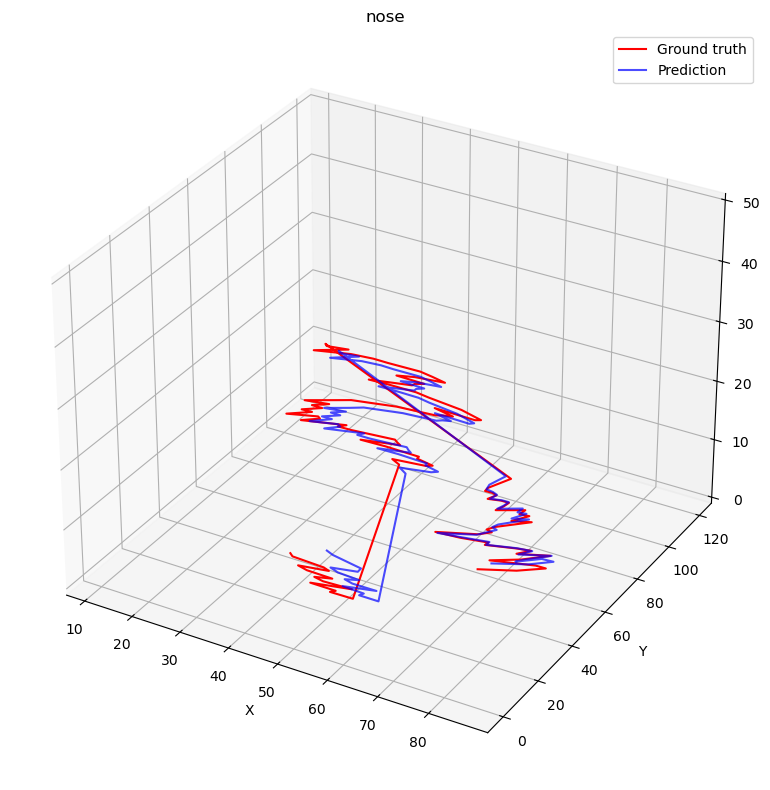

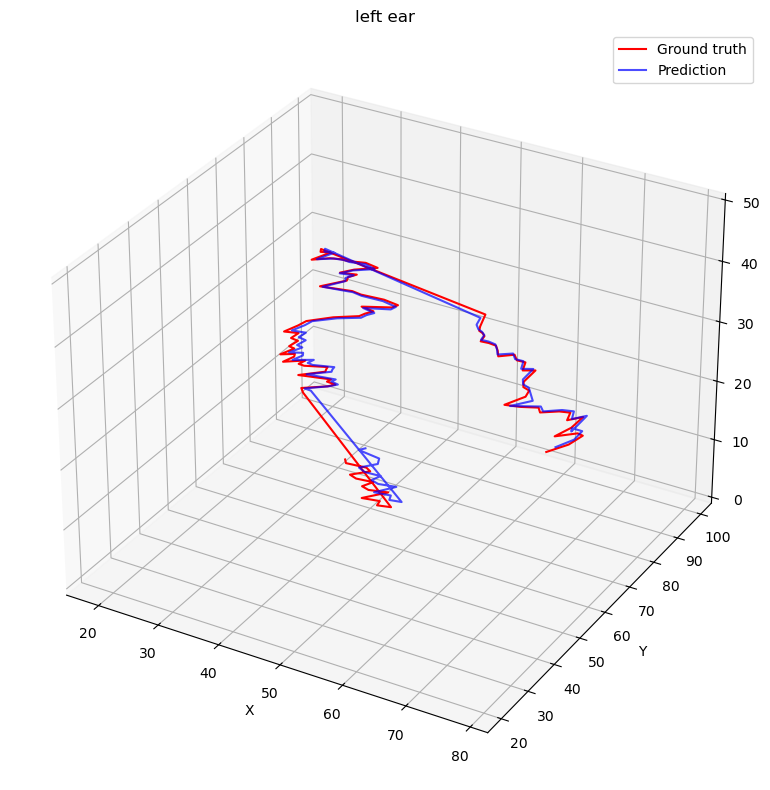

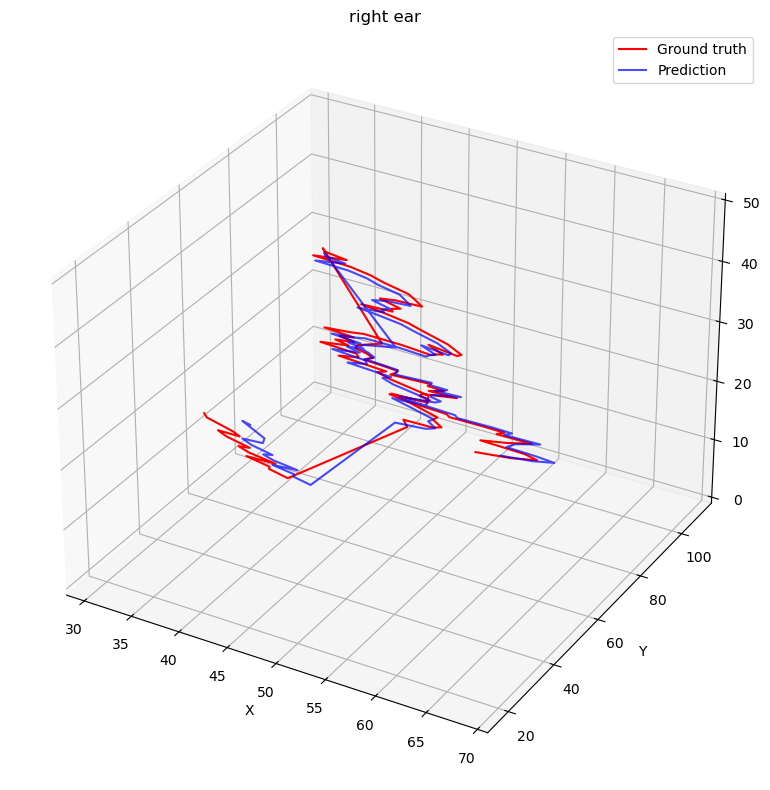

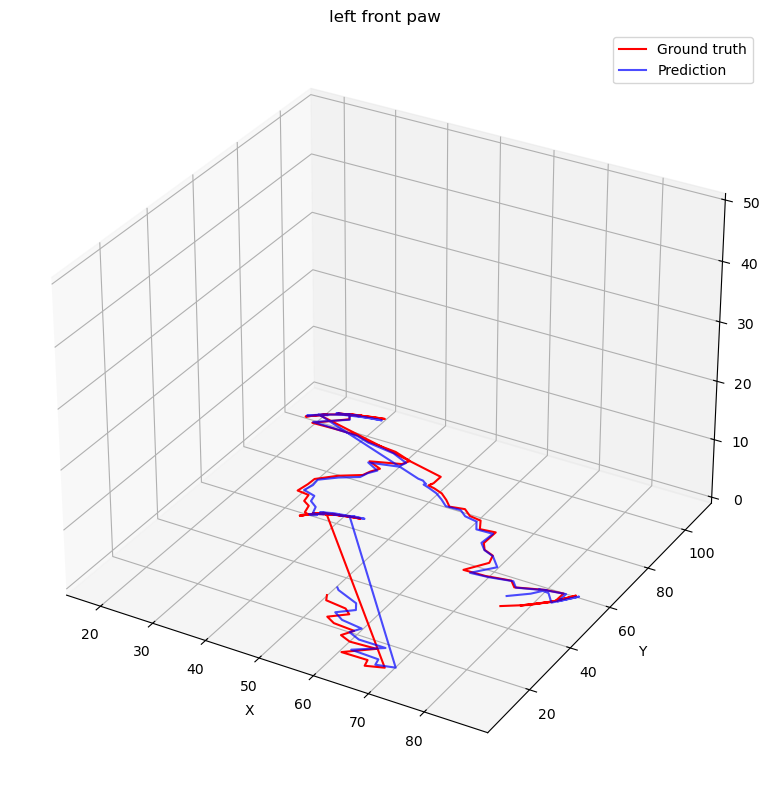

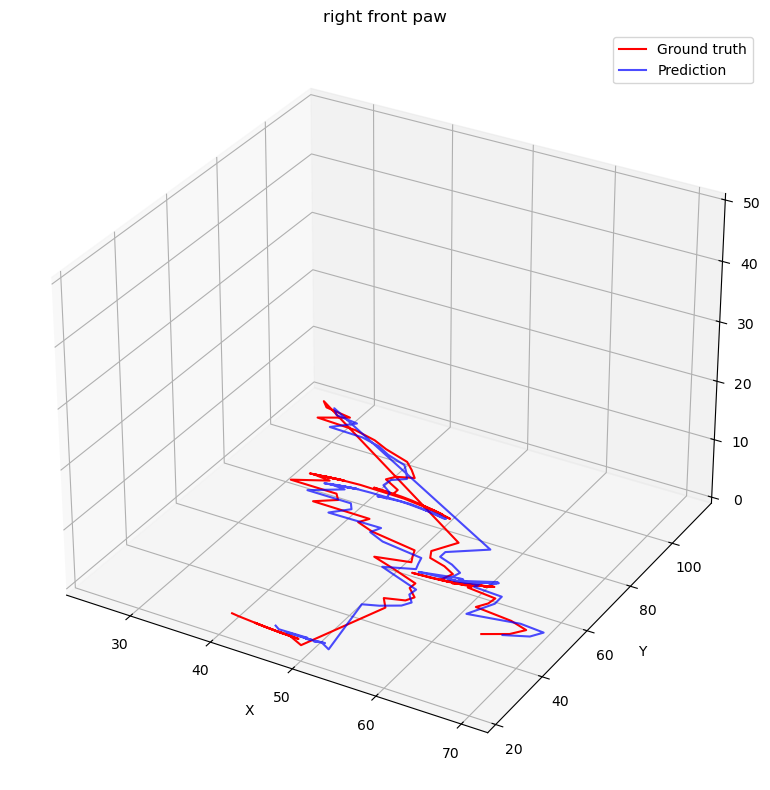

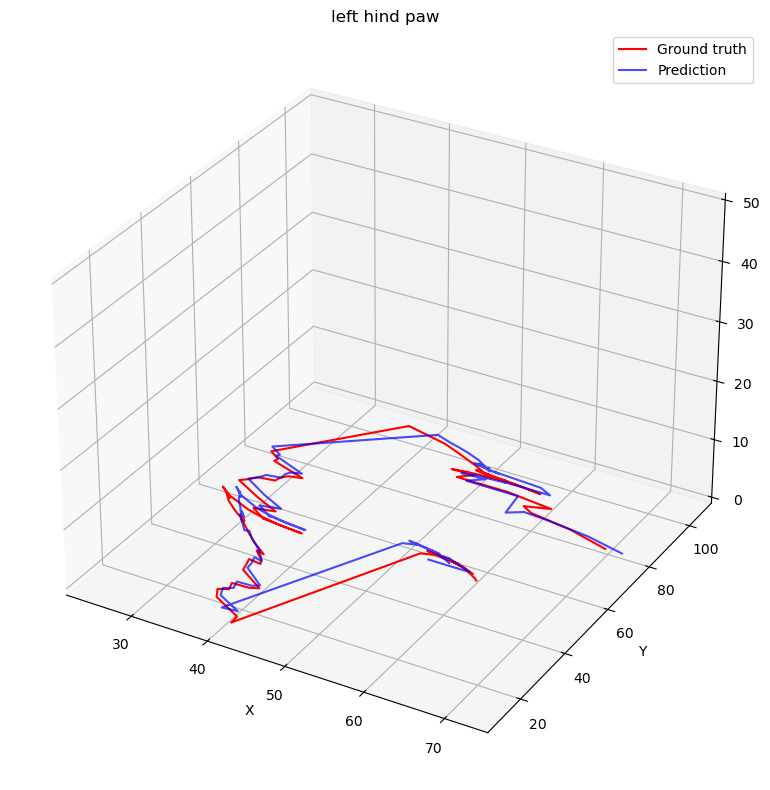

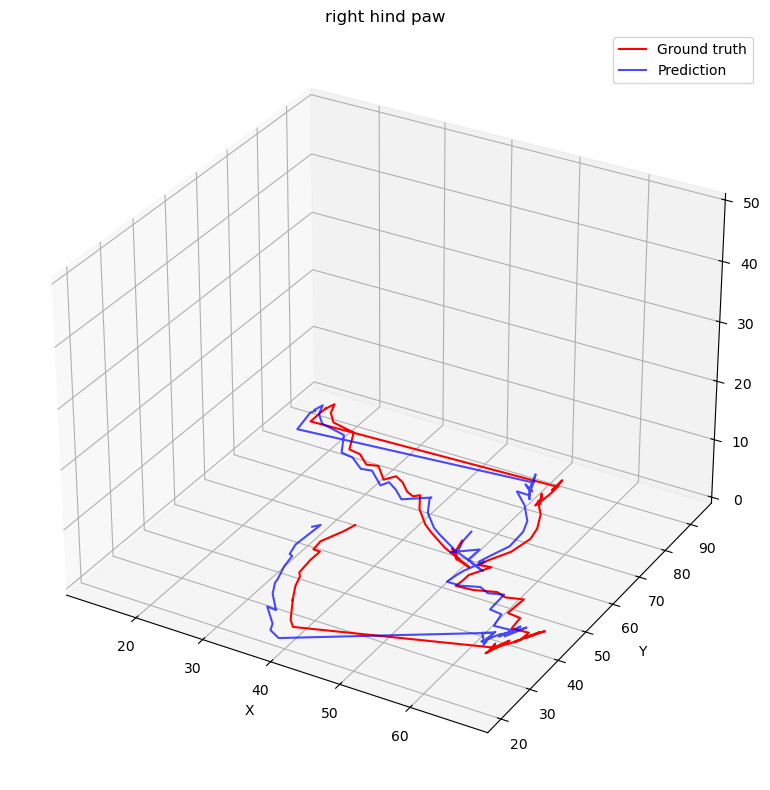

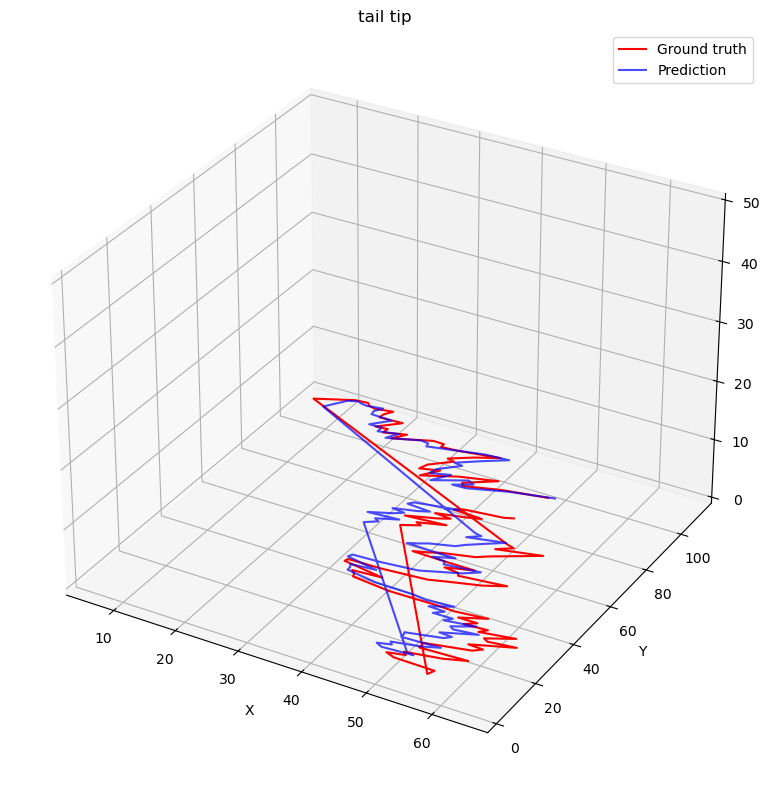

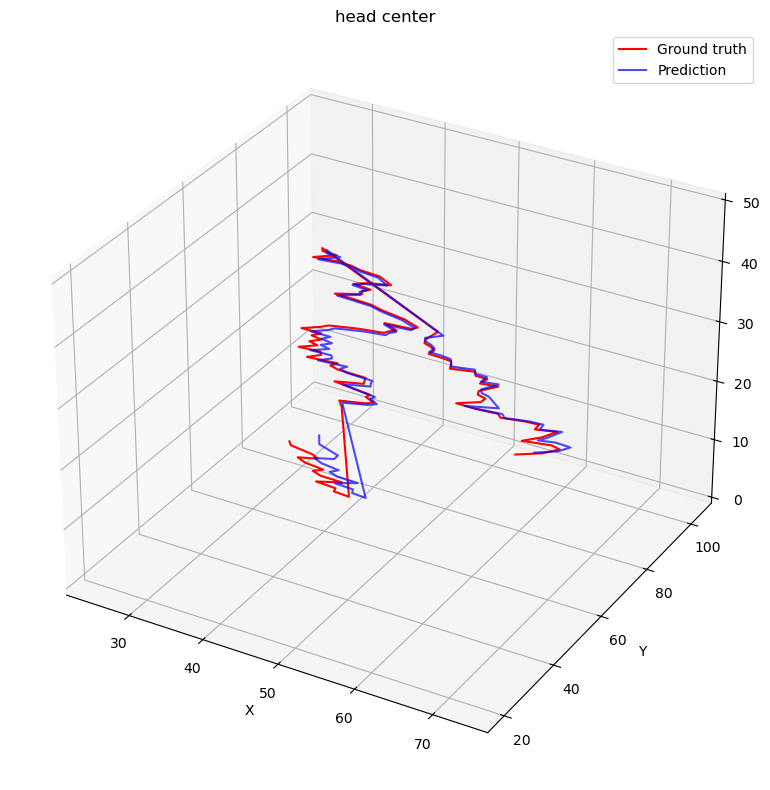

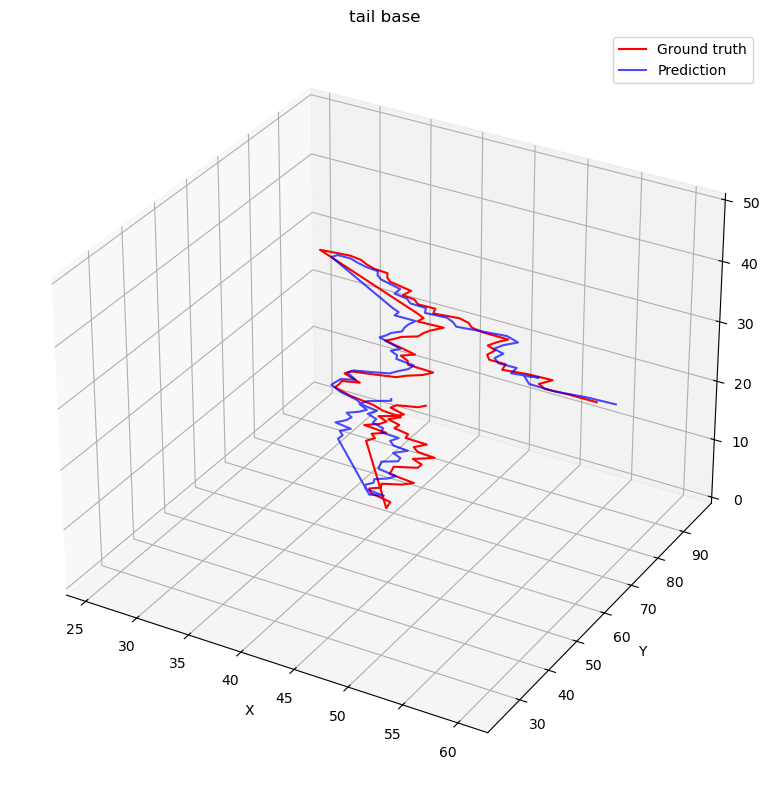

In [7]:
plot_tracks(y_nnorm, pred_nnorm, n_batch)

## Skeleton

In [8]:
# Select the instant to plot
n_batch = 8
t = 97

### Ground-truth

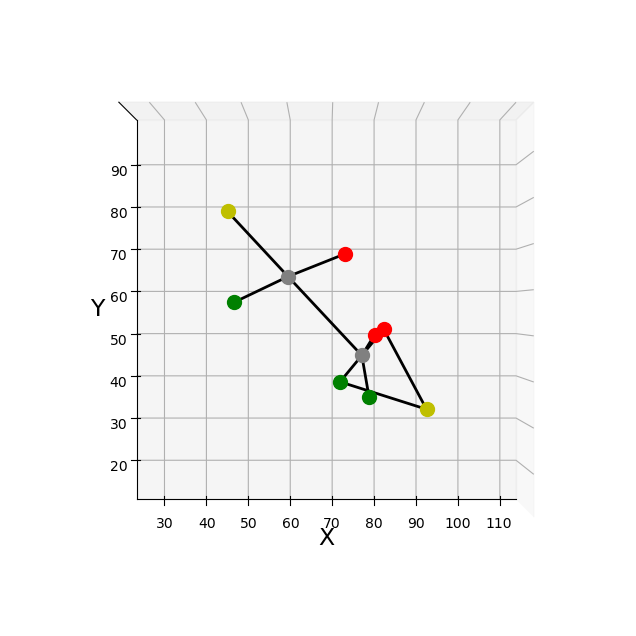

In [9]:
parts, skeleton = body(y_nnorm, n_batch, t)
bounds = plot_mouse(parts, skeleton, bounds=None)

### Masked

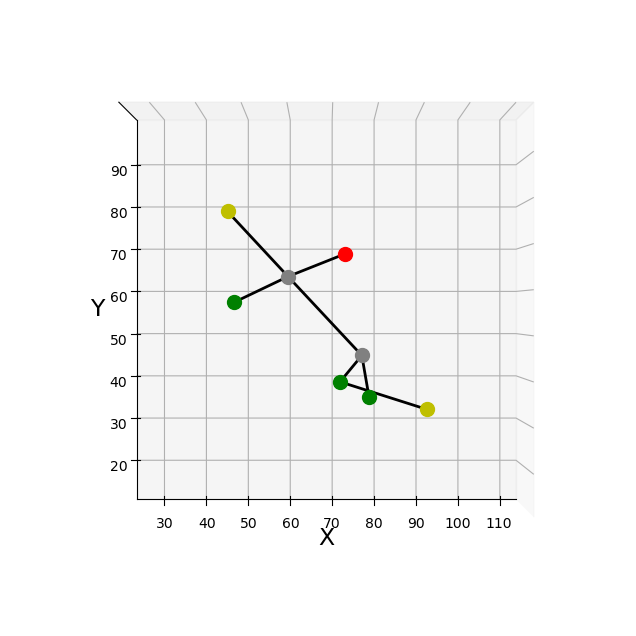

In [10]:
parts, skeleton = body(x_nnorm, n_batch, t)
plot_mouse(parts, skeleton, bounds=bounds)

### Prediction

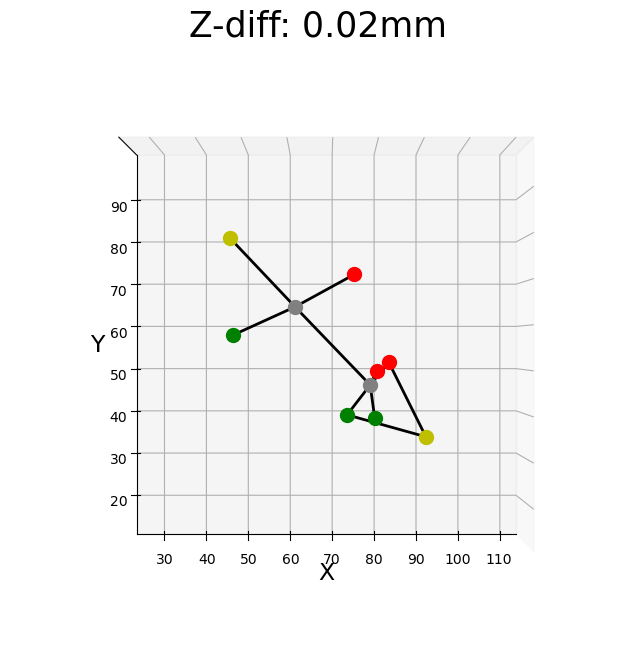

In [11]:
# Compute the average difference on the Z-axis between the ground truth and the prediction
z_diff = abs(pred_nnorm[n_batch , t, :, 2] - y_nnorm[n_batch , t, :, 2]).mean().item()

parts, skeleton = body(pred_nnorm, n_batch, t)
plot_mouse(parts, skeleton, bounds=bounds, z_diff=z_diff)